## Service Time vs Batch Size (from Triton `stats.json` + `perf_analyzer` stdout)

This notebook parses:
- `perf_raw/rps_*.stdout.txt` (offered load + throughput + latency breakdown)
- `perf_raw/stats.json` (Triton model stats with `batch_stats`)

and plots **average `compute_infer` time vs batch size** using Triton `batch_stats`.

In [1]:
%pip -q install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re, json
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Make sure to change the dir for each experiment!
RUN_DIR = Path.home() / 'results/food_classifier_onnx_poisson_dynamic_batch_max_16500rps_20260315T201931Z'
RAW_DIR = RUN_DIR / 'perf_raw'

stdout_files = sorted(RAW_DIR.glob('rps_*.stdout.txt'))
stats_path = RUN_DIR / 'stats.json'

print('RAW_DIR:', RAW_DIR)
print('Found stdout files:', len(stdout_files))
print('stats.json exists:', stats_path.exists())

RAW_DIR: /home/jovyan/results/food_classifier_onnx_poisson_dynamic_batch_max_16500rps_20260315T201931Z/perf_raw
Found stdout files: 1
stats.json exists: True


In [12]:
def _find_float(pattern: str, text: str):
    m = re.search(pattern, text, re.MULTILINE)
    return float(m.group(1)) if m else None

def _find_int(pattern: str, text: str):
    m = re.search(pattern, text, re.MULTILINE)
    return int(m.group(1)) if m else None

def parse_stdout(text: str) -> dict:
    d = {}
    d['Batch size (client)'] = _find_int(r'Batch size:\s+(\d+)', text)
    d['Request Rate'] = _find_float(r'Request Rate:\s+([0-9.]+)\s+inference requests per second', text)
    d['Throughput'] = _find_float(r'Throughput:\s+([0-9.]+)\s+infer/sec', text)
    d['Client p99 latency (usec)'] = _find_float(r'p99 latency:\s+([0-9.]+)\s+usec', text)
    d['Client delayed %'] = _find_float(r'(\d+(?:\.\d+)?)% of the requests were delayed', text)
    # Server breakdown (usec)
    d['Server Queue (usec)'] = _find_float(r'queue\s+([0-9.]+)\s+usec', text)
    d['Server Compute Infer (usec)'] = _find_float(r'compute infer\s+([0-9.]+)\s+usec', text)
    return d

In [13]:
# Build a perf_analyzer summary table from stdout files
rows = []
for f in stdout_files:
    txt = f.read_text(errors='replace')
    d = parse_stdout(txt)
    m = re.search(r'rps_(\d+)\.stdout\.txt$', f.name)
    d['rps_from_filename'] = int(m.group(1)) if m else None
    if d.get('Request Rate') is None and d['rps_from_filename'] is not None:
        d['Request Rate'] = float(d['rps_from_filename'])
    d['file'] = f.name
    rows.append(d)

df_perf = pd.DataFrame(rows)
if len(df_perf) == 0:
    print('No stdout files found. Double-check RUN_DIR/RAW_DIR and that filenames match rps_*.stdout.txt')
else:
    if 'Request Rate' in df_perf.columns:
        df_perf = df_perf.sort_values('Request Rate').reset_index(drop=True)
    display(df_perf.head())
    #save
    out_csv = RUN_DIR / 'perf_summary.csv'
    df_perf.to_csv(out_csv, index=False)
    print('Wrote:', out_csv)

,Batch size (client),Request Rate,Throughput,Client p99 latency (usec),Client delayed %,Server Queue (usec),Server Compute Infer (usec),rps_from_filename,file
0,1,500.0,506.83,1025114.0,1.54,36070.0,4275.0,500,rps_500.stdout.txt


Wrote: /home/jovyan/results/food_classifier_onnx_poisson_dynamic_batch_max_16500rps_20260315T201931Z/perf_summary.csv


In [14]:
# Parse Triton stats.json to get service time by batch size 
if not stats_path.exists():
    raise FileNotFoundError(f'Missing stats.json at: {stats_path}')

stats = json.loads(stats_path.read_text())

# Expected format: {"model_stats": [ { ... "batch_stats": [ {"batch_size":..., "compute_infer": {"count":..., "ns":...}}, ...] } ] }
model_stats = stats.get('model_stats', [])
if not model_stats:
    raise ValueError('stats.json has no model_stats entries')

ms0 = model_stats[0]
batch_stats = ms0.get('batch_stats', [])
if not batch_stats:
    raise ValueError('stats.json has no batch_stats entries (no batching observed?)')

records = []
for b in batch_stats:
    bs = b.get('batch_size')
    ci = (b.get('compute_infer') or {})
    cnt = ci.get('count')
    ns = ci.get('ns')
    if bs is None or cnt in (None, 0) or ns is None:
        continue
    avg_ms = (ns / cnt) / 1e6
    records.append({
        'batch_size': int(bs),
        'compute_infer_count': int(cnt),
        'compute_infer_total_ns': int(ns),
        'avg_compute_infer_ms': float(avg_ms),
    })

df_service = pd.DataFrame(records).sort_values('batch_size').reset_index(drop=True)
df_service.to_json(RAW_DIR / "compute_vs_batch_size.json", orient="records", indent=2)
display(df_service)

,batch_size,compute_infer_count,compute_infer_total_ns,avg_compute_infer_ms
0,1,68463,150131889979,2.192891
1,2,20161,42388658319,2.102508
2,3,8063,17976222543,2.229471
3,4,1073,3208435032,2.990154
4,5,727,2567127687,3.531125
5,6,203,1392113226,6.857701
6,7,134,1303882448,9.730466
7,8,57,1136454516,19.937799
8,9,41,1117982230,27.267859
9,10,20,1068330287,53.416514


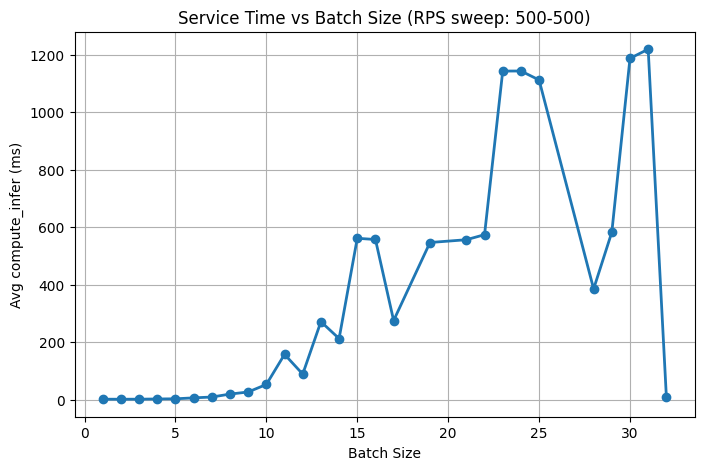

In [15]:
# Plot service time vs batch size (from stats.json) 
plt.figure(figsize=(8,5))
plt.plot(df_service['batch_size'], df_service['avg_compute_infer_ms'], marker='o', linewidth=2)
plt.xlabel('Batch Size')
plt.ylabel('Avg compute_infer (ms)')

# A helpful title: include offered load range if we have stdout
title = 'Service Time vs Batch Size'
if len(stdout_files) > 0 and len(df_perf) > 0 and 'Request Rate' in df_perf.columns:
    rps_min = float(df_perf['Request Rate'].min())
    rps_max = float(df_perf['Request Rate'].max())
    title = f'Service Time vs Batch Size (RPS sweep: {rps_min:.0f}-{rps_max:.0f})'
plt.title(title)

plt.grid(True)
plt.savefig(RAW_DIR / "queue_vs_theory_plot.png", dpi=300, bbox_inches="tight")
plt.show()